# **Importando as Bibliotecas**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import  classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
import random
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# **Carregando o Dataset**

In [2]:
# Carregar o dataset
wine_red = pd.read_csv('winequality-red.csv', sep=';')

In [3]:
wine_red.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


# **Aplicando a PCA e verificando quantos componentes são necessários para 80% de variancia.**

In [4]:
# Separar as features e o rótulo
X = wine_red.drop('quality', axis=1).values  # Features
y = wine_red['quality'].values  # Target

In [5]:
#Normalizando
sc = StandardScaler()
X_norm = sc.fit_transform(X)

In [6]:
#Inicializando a classe PCA feita em aula
class PCA_J():

    #Class responsible for the PCA initialization
    def __init__(self, norm=True, components = None):
        self.mean = None
        self.components = components
        self.norm = norm # Initialize the norm attribute


    # Normalizando os dados
    def normalize(self, X):
        sc = StandardScaler()
        X_norm = sc.fit_transform(X)
        return X_norm

    def fit(self, X):
      if self.norm:
        X_norm = X
      else:
        X_norm = self.normalize(X)

    # Calculando a Matriz de covariancia
      mat_cov = np.cov(X_norm.T)

    # Realiznando o Single Value Decomposition
      self.U, self.S, self.V = np.linalg.svd(mat_cov)

    # Selecionando os k primeiros componentes
      self.princip_comp = self.U[:, :self.components]

    # Calculando a matriz projetada
      self.X_proj = X.dot(self.princip_comp)

    # Calcula e armazena a taxa de variância explicada
      self.explained_variance_ratio_ = self.S / np.sum(self.S)

    # Transformando os dados
    def transform(self, A):
        return A.dot(self.princip_comp)

In [7]:
# Aplicar o PCA
PCA = PCA_J()
PCA.fit(X_norm)

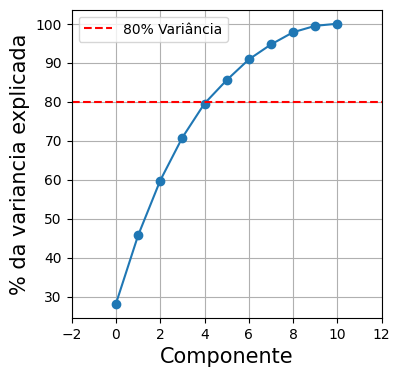

In [8]:
# Análise dos Componentes

def component_analysis(e, plot='none'):
    varexp = 100* e/e.sum()
    cumvarexp = np.cumsum(varexp)

    # Plotando a explicação da variancia
    if (plot=='varexp'):
        plt.figure(figsize = (4,4))
        plt.plot(cumvarexp, '-o')
        plt.xlabel('Componente', fontsize = 15)
        plt.ylabel('% da variancia explicada', fontsize = 15)
        plt.axhline(y=80, color='r', linestyle='--', label='80% Variância')
        plt.legend(loc='best')
        plt.grid(True)
        xint = []
        locs, labels = plt.xticks()
        for each in locs:
            xint.append(int(each))
        plt.xticks(xint)

    plt.show()

# Visualização - plot=['eigen', 'varexp']

component_analysis(PCA.S, plot='varexp')

In [9]:
# Variância explicada acumulada
explained_variance = np.cumsum(PCA.explained_variance_ratio_)

In [10]:
# Determinar o número de componentes para 80% de variância
components_80 = np.argmax(explained_variance >= 0.80) + 1
print(f"Número de componentes para 80% de variância: {components_80}")

Número de componentes para 80% de variância: 6


# **Reduzindo os componentes necessários que explicam 80% de variância e utilizando-os nos modelos Gaussian e KNN**

In [11]:
# Reduzir os dados para o número de componentes que explicam 80% da variância
PCA_80 = PCA_J(components=components_80)
PCA_80.fit(X)
X_80 = PCA_80.transform(X)

In [12]:
# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_80, y, test_size=0.2, random_state=42)

In [13]:
# Aplicar GaussianNB
GNB = GaussianNB()
GNB.fit(X_train, y_train)
y_pred_gnb = GNB.predict(X_test)

In [14]:
# Aplicar KNN
KNN = KNeighborsClassifier()
KNN.fit(X_train, y_train)
y_pred_knn = KNN.predict(X_test)

In [15]:
# Gerar o Classification Report para GaussianNB
print("Classification Report for GaussianNB:")
print(classification_report(y_test, y_pred_gnb))

Classification Report for GaussianNB:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.60      0.72      0.65       130
           6       0.50      0.52      0.51       132
           7       0.26      0.12      0.16        42
           8       0.00      0.00      0.00         5

    accuracy                           0.52       320
   macro avg       0.23      0.23      0.22       320
weighted avg       0.48      0.52      0.50       320



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
# Gerar o Classification Report para KNN
print("Classification Report for KNN:")
print(classification_report(y_test, y_pred_knn))

Classification Report for KNN:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.49      0.64      0.55       130
           6       0.44      0.44      0.44       132
           7       0.31      0.12      0.17        42
           8       0.00      0.00      0.00         5

    accuracy                           0.46       320
   macro avg       0.21      0.20      0.19       320
weighted avg       0.42      0.46      0.43       320



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
